In [14]:

#!/usr/bin/env python3
"""
Designing a convolutional linear data preconditioner for MNIST diffusion
DESIGNED IN [-1,1] space

Implements LP feasibility problem + bisection over gamma
optimizing over Fourier-domain weights s (for M^T M) and s_max, then constructs

    M = F^* diag(sqrt(s)) F

as a 784x784 *explicit* dense matrix (numpy array), with M acting on vec(X) where vec is
row-major flatten of a 28x28 image.
"""



'\nDesigning a convolutional linear data preconditioner for MNIST diffusion\nDESIGNED IN [-1,1] space\n\nImplements LP feasibility problem + bisection over gamma\noptimizing over Fourier-domain weights s (for M^T M) and s_max, then constructs\n\n    M = F^* diag(sqrt(s)) F\n\nas a 784x784 *explicit* dense matrix (numpy array), with M acting on vec(X) where vec is\nrow-major flatten of a 28x28 image.\n'

In [15]:
import math
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
import cvxpy as cp
from itertools import product
import matplotlib.pyplot as plt

In [16]:
# -----------------------------
# Dimensions
# -----------------------------
H = 28 
W = 28 
D = H * W  



In [17]:
# -----------------------------
# Vectorization (any fixed vec; we choose row-major)
# -----------------------------
def vec_img(x_hw: np.ndarray) -> np.ndarray:
    """vec: R^{H x W} -> R^D, row-major."""
    return x_hw.reshape(-1)  # row-major


def unvec_img(x_d: np.ndarray) -> np.ndarray:
    """inverse vec: R^D -> R^{H x W}, row-major."""
    return x_d.reshape(H, W)



In [18]:
# -----------------------------
# Diffusion schedule -> g(t)
# -----------------------------
def ddpm_g_from_linear_beta_schedule(
    T_steps: int = 400,               
    beta_start: float = 1e-4,         
    beta_end: float = 0.02,           
    clamp_eps: float = 1e-12,         
) -> np.ndarray:
    """
    Computes g(t) = alpha(t)^2 / sigma_t^2 using the discrete DDPM marginal:
        x_t = sqrt(alpha_bar[t]) x0 + sqrt(1 - alpha_bar[t]) eps
    so:
        alpha(t)^2  = alpha_bar[t]
        sigma_t^2   = 1 - alpha_bar[t]
        g(t)        = alpha_bar[t] / (1 - alpha_bar[t])
    """
    betas = torch.linspace(beta_start, beta_end, T_steps, device="cpu")  
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)  
    denom = torch.clamp(1.0 - alpha_bar, min=clamp_eps)
    g = (alpha_bar / denom).detach().cpu().numpy().astype(np.float64)    
    return g

In [19]:
# -----------------------------
# Dataset: MNIST 
# -----------------------------

# MNIST 
def load_mnist_train():
    tfm = T.Compose([T.ToTensor(), T.Lambda(lambda x: x * 2.0 - 1.0)])  # gives [1,28,28] in [-1,1]
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
    return ds


# # --------------------------------------------------
# # Dataset: Pattern-MNIST 
# # Returns an MNIST-type object
# # 0 vertical stripes
# # 1 horizontal stripes
# # 2 checkerboard
# # 3 diagonal stripes 
# # 4 diagonal stripes
# # 5 plus
# # 6 X
# # 7 square ring
# # 8 filled circle
# # 9 circle ring
# # --------------------------------------------------

# def _pattern_bank():
#     y, x = torch.meshgrid(torch.arange(28), torch.arange(28), indexing="ij")
#     r2 = (x - 13.5) ** 2 + (y - 13.5) ** 2
#     m = torch.maximum((x - 14).abs(), (y - 14).abs())

#     pats = [
#         (x // 4) % 2 == 0,
#         (y // 4) % 2 == 0,
#         ((x // 4 + y // 4) % 2) == 0,
#         ((x - y) % 6) < 3,
#         ((x + y) % 6) < 3,
#         ((x - 14).abs() <= 2) | ((y - 14).abs() <= 2),
#         ((x - y).abs() <= 2) | ((x + y - 27).abs() <= 2),
#         (m >= 7) & (m <= 9),
#         r2 <= 8**2,
#         (r2 >= 6**2) & (r2 <= 10**2),
#     ]

#     return 255 * torch.stack([p.to(torch.uint8) for p in pats])  # [10,28,28]


# def _make_pattern_split(train=True):
#     n_per_class = 6000 if train else 1000
#     g = torch.Generator().manual_seed(0 if train else 1)

#     data = _pattern_bank().repeat_interleave(n_per_class, dim=0).float()   # [N,28,28]
#     data += 25.0 * torch.randn(data.shape, generator=g)                     # small noise
#     data = data.clamp(0, 255).to(torch.uint8)

#     targets = torch.arange(10).repeat_interleave(n_per_class)
#     perm = torch.randperm(len(targets), generator=g)
#     return data[perm], targets[perm]


# def load_mnist_train():
#     tfm = T.Compose([T.ToTensor(), T.Lambda(lambda x: x * 2.0 - 1.0)])  # [1,28,28] in [-1,1]

#     ds = torchvision.datasets.MNIST.__new__(torchvision.datasets.MNIST)
#     torchvision.datasets.VisionDataset.__init__(ds, root="./data", transform=tfm, target_transform=None)

#     ds.train = True
#     ds.data, ds.targets = _make_pattern_split(train=True)
#     ds.classes = [f"pattern_{i}" for i in range(10)]

#     return ds

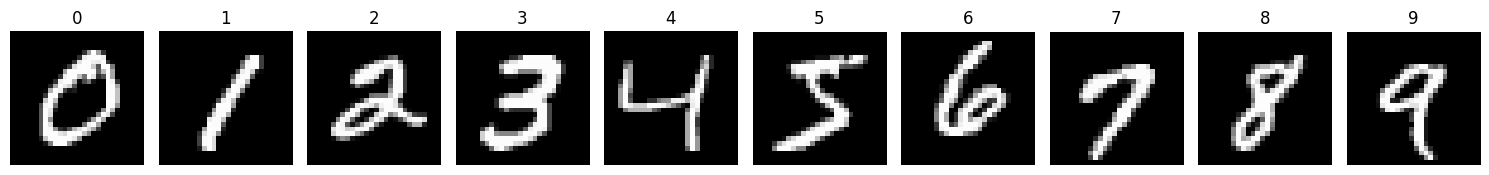

In [20]:
# -----------------------------
# Visualize dataset
# -----------------------------
ds = load_mnist_train()

fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for c in range(10):
    idx = (ds.targets == c).nonzero(as_tuple=True)[0][0].item()
    x, y = ds[idx]                      # dim of x is [28,28] in [-1,1]
    img = (x.squeeze().cpu() + 1) / 2   # [0,1] for display

    axes[c].imshow(img, cmap="gray")
    axes[c].set_title(str(y))
    axes[c].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# -----------------------------
# Compute class means mu_i 
# -----------------------------
def get_class_means(
    mnist_train,
    placeholder_seed: int = 0,            
    max_per_class: int = 5000,      
) -> np.ndarray:
    """
    Returns mu[i] as 28x28 arrays, shape [10, H, W].
    """

    sums = np.zeros((10, H, W), dtype=np.float64)
    counts = np.zeros((10,), dtype=np.int64)

    for x, y in mnist_train:
        yi = int(y)
        if counts[yi] >= max_per_class:
            if np.all(counts >= max_per_class):
                break
            continue
        x_hw = x[0].numpy().astype(np.float64)
        sums[yi] += x_hw
        counts[yi] += 1

    for i in range(10):
        if counts[i] == 0:
            raise RuntimeError(f"No samples collected for class {i}")
    mu = sums / counts[:, None, None]
    return mu

In [22]:
# -----------------------------
# D_close / D_far construction
# -----------------------------
def pairs_within(classes):
    cs = sorted(list(classes))
    out = []
    for a in range(len(cs)):
        for b in range(a + 1, len(cs)):
            out.append((cs[a], cs[b]))
    return out


def pairs_across(intra_classes, inter_classes):
    out = []
    for i in sorted(list(intra_classes)):
        for j in sorted(list(inter_classes)):
            if i == j:
                raise ValueError("intra_classes and inter_classes must be disjoint.")
            out.append((i, j))
    return out


def abs_dhat_sq_from_means(mu_hw: np.ndarray, pair_list):
    """
    For each (i,j) in pair_list, compute d = mu_i - mu_j (28x28),
    then d_hat = FFT2(d, norm='ortho'), and return |d_hat|^2 flattened (row-major).
    Returns A of shape [num_pairs, D], dtype float64.
    """
    A = []
    for (i, j) in pair_list:
        d_hw = (mu_hw[i] - mu_hw[j]).astype(np.float64)
        d_hat = np.fft.fft2(d_hw, norm="ortho")  # complex [H,W]
        A.append((np.abs(d_hat) ** 2).reshape(-1))  # flatten row-major
    if len(A) == 0:
        return np.zeros((0, D), dtype=np.float64)
    return np.stack(A, axis=0).astype(np.float64)


# -----------------------------
# Symmetry constraints
# -----------------------------
def symmetry_index_pairs(H_, W_):
    """
    Returns list of (idx, mirror_idx) with idx < mirror_idx, where:
        mirror(k,l) = ((H-k)%H, (W-l)%W)
    in row-major flattening idx = k*W + l.
    """
    pairs = []
    for k in range(H_):
        for l in range(W_):
            kk = (-k) % H_
            ll = (-l) % W_
            idx = k * W_ + l
            midx = kk * W_ + ll
            if idx < midx:
                pairs.append((idx, midx))
    return pairs



In [23]:
# -----------------------------
# LP builder
# -----------------------------
def build_lp_problem(
    A_close: np.ndarray,
    A_far: np.ndarray,
    g_grid: np.ndarray,
    delta_close: float,      
    sigma0: float,           
    eps_s: float,            
):
    
    assert A_close.shape[1] == D and A_far.shape[1] == D
    s = cp.Variable(D)          
    s_max = cp.Variable()       
    gamma_sq = cp.Parameter(nonneg=True)  

    constraints = []

    constraints += [s_max >= 0]
    constraints += [s >= eps_s]
    constraints += [s <= s_max]

    for idx, midx in symmetry_index_pairs(H, W):
        constraints += [s[idx] == s[midx]]
    
    if A_close.shape[0] > 0:
        for g in g_grid:
            constraints += [g * (A_close @ s) <= (delta_close ** 2) * np.ones(A_close.shape[0])]

   
    if A_far.shape[0] > 0:
        for g in g_grid:
            rhs = gamma_sq * (1.0 + (sigma0 ** 2) * g * s_max)  # scalar affine in s_max
            constraints += [g * (A_far @ s) >= rhs * np.ones(A_far.shape[0])]

    objective = cp.Minimize(s_max)

    # # -------- objective function alternative --------
    # lowpass_strength = 1e-2
    # k = np.minimum(np.arange(H), H - np.arange(H))
    # l = np.minimum(np.arange(W), W - np.arange(W))
    # radius_sq_hw = (k[:, None] ** 2 + l[None, :] ** 2).astype(np.float64)

    # freq_penalty = radius_sq_hw.reshape(-1)
    # freq_penalty /= (freq_penalty.mean() + 1e-12)
    # freq_penalty[0] = 0.0

    # objective = cp.Minimize(
    #     s_max + lowpass_strength * (freq_penalty @ s)
    # )


    # -------- return optimization problem --------
    problem = cp.Problem(objective, constraints)
    return problem, s, s_max, gamma_sq





In [24]:
# -----------------------------
# Bisection on gamma
# -----------------------------
def bisect_max_gamma(
    problem,
    s_var,
    smax_var,
    gamma_sq_param,
    gamma_hi_init: float = 1.0,
    gamma_hi_max: float = 1e3,
    bisection_iters: int = 25,
    solver: str = "SCS",
    verbose_solver: bool = False,   # False suppress solver spam
    print_progress: bool = True,    # one-line progress logs
):
    """
    Monotone search (bracketing + bisection) for max feasible gamma.
    Returns: (gamma_star, s_star, smax_star, history)

    history is a dict with arrays you can plot:
      - attempted_gamma[k]
      - feasible[k] (bool)
      - best_feasible_gamma[k]
      - phase[k] in {"bracket","bisect"}
    """

    history = {
        "phase": [],
        "attempted_gamma": [],
        "feasible": [],
        "best_feasible_gamma": [],
        "status": [],
    }

    def log(phase, gamma, ok, best, status):
        history["phase"].append(phase)
        history["attempted_gamma"].append(float(gamma))
        history["feasible"].append(bool(ok))
        history["best_feasible_gamma"].append(float(best))
        history["status"].append(str(status))

    def solve_for_gamma(gamma):
        gamma_sq_param.value = float(gamma * gamma)
        try:
            problem.solve(solver=solver, verbose=verbose_solver)
        except Exception as e:
            # Treat solver error as infeasible, but record status clearly
            return False, None, None, f"error: {type(e).__name__}"

        status = problem.status
        ok = status in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE)
        if ok:
            s_val = np.array(s_var.value).reshape(-1).astype(np.float64)
            smax_val = float(smax_var.value)
            return True, s_val, smax_val, status
        return False, None, None, status

    # --- Check gamma=0 feasibility (should be feasible; otherwise constraints too tight)
    ok0, s0, smax0, st0 = solve_for_gamma(0.0)
    log("bracket", 0.0, ok0, 0.0 if ok0 else 0.0, st0)
    if print_progress:
        print(f"[bracket] gamma=0.0 -> {'FEASIBLE' if ok0 else 'INFEASIBLE'} (status={st0})")

    if not ok0:
        raise RuntimeError(
            "LP infeasible even at gamma=0. "
            "This usually means close_constraints + eps_s are too strict."
        )

    gamma_lo = 0.0
    s_best, smax_best = s0, smax0

    # --- Bracket upper bound by doubling until infeasible
    gamma_hi = float(gamma_hi_init)
    while gamma_hi <= gamma_hi_max:
        ok, s_val, smax_val, st = solve_for_gamma(gamma_hi)
        if ok:
            gamma_lo = gamma_hi
            s_best, smax_best = s_val, smax_val
            log("bracket", gamma_hi, True, gamma_lo, st)
            if print_progress:
                print(f"[bracket] gamma={gamma_hi:.6g} -> FEASIBLE (best={gamma_lo:.6g})")
            gamma_hi *= 2.0
        else:
            log("bracket", gamma_hi, False, gamma_lo, st)
            if print_progress:
                print(f"[bracket] gamma={gamma_hi:.6g} -> INFEASIBLE (best={gamma_lo:.6g}, status={st})")
            break

    gamma_hi = min(gamma_hi, gamma_hi_max)

    # --- Bisection
    for it in range(bisection_iters):
        mid = 0.5 * (gamma_lo + gamma_hi)
        ok, s_val, smax_val, st = solve_for_gamma(mid)

        if ok:
            gamma_lo = mid
            s_best, smax_best = s_val, smax_val
            log("bisect", mid, True, gamma_lo, st)
            if print_progress:
                print(f"[bisect {it:02d}] gamma={mid:.6g} -> FEASIBLE (best={gamma_lo:.6g})")
        else:
            gamma_hi = mid
            log("bisect", mid, False, gamma_lo, st)
            if print_progress:
                print(f"[bisect {it:02d}] gamma={mid:.6g} -> INFEASIBLE (best={gamma_lo:.6g}, status={st})")

    return gamma_lo, s_best, smax_best, history

In [25]:
# -----------------------------
# Construct M 784x784 from s*
# -----------------------------
def apply_M_fft(x_hw: np.ndarray, sqrt_s_hw: np.ndarray) -> np.ndarray:
    """
    Y = M X via Fourier-domain rule:
      X_hat = DFT2(X), Y_hat = sqrt(s) * X_hat, Y = IDFT2(Y_hat)
    """
    X_hat = np.fft.fft2(x_hw, norm="ortho")
    Y_hat = sqrt_s_hw * X_hat
    y_hw = np.fft.ifft2(Y_hat, norm="ortho")
    y_hw = np.real_if_close(y_hw, tol=1e3)  # should be real if symmetry satisfied
    return np.asarray(y_hw, dtype=np.float64)


def build_dense_M_from_s(s_hw: np.ndarray) -> np.ndarray:
    assert s_hw.shape == (H, W)
    sqrt_s_hw = np.sqrt(s_hw)

    M = np.zeros((D, D), dtype=np.float64)
    for p in range(D):
        e = np.zeros((D,), dtype=np.float64)
        e[p] = 1.0
        e_hw = unvec_img(e)
        y_hw = apply_M_fft(e_hw, sqrt_s_hw)
        M[:, p] = vec_img(y_hw)
    return M




In [26]:
# ------------------------------------------------------------
# View the *spatial convolution mask/kernel* corresponding to s[ω]
# (consistent with the same row/column stacking used when building M)
#
# Recall: M = F^* diag(sqrt(s)) F
# So sqrt(s)[k,l] is the frequency response, and the spatial kernel m[u,v]
# is the inverse 2D DFT of sqrt(s).
# ------------------------------------------------------------

def s_to_kernel_hw(s_flat: np.ndarray, clip_negative: bool = True) -> np.ndarray:
    """
    Convert s[ω] (flattened row-major over (k,l)) into the spatial kernel m[u,v].

    This matches the convention used in the earlier construction:
      - images are treated as (H,W) arrays
      - vec() is row-major flatten
      - frequency grid ω=(k,l) is stored row-major (k major, l minor)
      - FFT/IFFT use norm='ortho'
    """
    assert s_flat.shape == (H * W,), f"expected shape {(H*W,)}, got {s_flat.shape}"
    s_hw = s_flat.reshape(H, W).astype(np.float64)  # row-major -> (k,l) grid

    if clip_negative:
        # If your LP solver produced tiny negatives (e.g. -1e-6), clip for sqrt.
        s_hw = np.maximum(s_hw, 0.0)

    sqrt_s_hw = np.sqrt(s_hw)

    # Spatial kernel (circular convolution mask):
    # m = IDFT2( sqrt(s) )
    m_hw = np.fft.ifft2(sqrt_s_hw, norm="ortho")
    m_hw = np.real_if_close(m_hw, tol=1e3)  # should be real if symmetry constraints held
    return np.asarray(m_hw, dtype=np.float64)

def show_kernel_heatmap(s_flat: np.ndarray, center: bool = True, title: str = "Spatial convolution mask m[u,v]"):
    """
    Visualize the spatial kernel as a heatmap.
    - center=True uses fftshift so the (0,0) impulse position appears centered for readability.
      (Computation uses the unshifted kernel; shifting is only for display.)
    """

    #view in log(abs()) since it's hard to tell what's 0 or just very close since machine percision
    
    m_hw = np.log(np.abs(s_to_kernel_hw(s_flat)))

    m_vis = np.fft.fftshift(m_hw) if center else m_hw

    plt.figure(figsize=(5, 4))
    plt.title(title + (" ()" if center else ""))
    plt.imshow(m_vis, aspect="equal")
    plt.colorbar()
    plt.axis("off")
    plt.show()

    return m_hw  # return the kernel used by circular convolution


In [27]:
def search_mnist_preconditioner_hyperparams(
    search_space: dict,
    top_k: int = 2,
    T_steps: int = 400,
    beta_end: float = 0.02,
    placeholder_seed: int = 0,
    max_per_class: int = 5000,
    gamma_hi_init: float = 1.0,
    gamma_hi_max: float = 200.0,
    solver: str = "SCS",
    verbose_solver: bool = False,
    outer_print_progress: bool = True,
    inner_bisection_logs: bool = False,
    visualize_top_k: bool = True,
    center_kernel_display: bool = True,
    build_dense_M_for_top: bool = False,
):
    """
    Grid-search over:
      - intra_classes
      - inter_classes
      - time_grid
      - sigma0
      - eps_s
      - delta_close
      - beta_start
      - bisection_iters

    Parameters
    ----------
    search_space : dict
        Must contain the 8 keys above.

        Expected format:
          - search_space["intra_classes"] : list of class collections
                e.g. [{8}, {3}, {3,8}]
          - search_space["inter_classes"] : list of class collections
                e.g. [{1}, {0,1}]
          - search_space["time_grid"] : list of candidate time grids
                e.g. [[200], [50,51,52], [100,150,200]]
          - all others : list of scalar values

    Returns
    -------
    out : dict
        {
          "top_results": [...],   # length <= top_k, sorted best-first
          "all_results": [...],   # every attempted combo
          "mu_hw": mu_hw,         # cached class means used for all runs
        }

    Notes
    -----
    - This ranks kernels using the normalized mean circular distance of |kernel|
      away from (0,0). Higher = less impulse-like.
    - To keep the search practical, this does NOT build dense M for every combo.
      It only builds dense M for the top results if build_dense_M_for_top=True.
    """

    required_keys = [
        "intra_classes",
        "inter_classes",
        "time_grid",
        "sigma0",
        "eps_s",
        "delta_close",
        "beta_start",
        "bisection_iters",
    ]
    missing = [k for k in required_keys if k not in search_space]
    if missing:
        raise ValueError(f"search_space is missing keys: {missing}")

    # ---------
    # helpers
    # ---------
    def _as_class_set(x):
        if isinstance(x, (int, np.integer)):
            return {int(x)}
        return set(x)

    def _as_time_grid(x):
        if isinstance(x, (int, np.integer)):
            return [int(x)]
        return [int(t) for t in x]

    def _kernel_spread_score(kernel_hw: np.ndarray):
        """
        Score = normalized mean circular distance of |kernel| mass from (0,0).

        Also returns useful diagnostics:
          - origin_mass_frac
          - off_origin_mass_frac
        """
        mass = np.abs(np.asarray(kernel_hw, dtype=np.float64))
        total_mass = mass.sum()

        if (not np.isfinite(total_mass)) or total_mass <= 0:
            return -np.inf, {
                "origin_mass_frac": np.nan,
                "off_origin_mass_frac": np.nan,
                "mean_circular_distance": np.nan,
            }

        p = mass / total_mass

        # Circular distance on the 28x28 torus, since the operator is circular convolution
        du = np.minimum(np.arange(H), H - np.arange(H))
        dv = np.minimum(np.arange(W), W - np.arange(W))
        dist = np.sqrt(du[:, None] ** 2 + dv[None, :] ** 2)

        mean_dist = float((p * dist).sum())
        max_dist = float(dist.max()) + 1e-12
        score = mean_dist / max_dist

        '''
        score = sum[prob_mass(u,v) * d_circ((u,v), (0,0))] / normalize by max distance

        prob_mass(u,v) = m(u,v) / sum(m(a,b))

        d_circ((u,v), (0,0)) = sqrt ( d_H (u) + d_W ) for d_H (u) = min(u, 28-u)

        score = 0 when everything at (0,0)
        '''
 

        diagnostics = {
            "origin_mass_frac": float(p[0, 0]),
            "off_origin_mass_frac": float(1.0 - p[0, 0]),
            "mean_circular_distance": float(score),
        }
        return float(score), diagnostics

    # ----------------------------------------------------
    # Cache MNIST + class means once for the whole search
    # ----------------------------------------------------
    mnist_train = load_mnist_train()
    mu_hw = get_class_means(
        mnist_train,
        placeholder_seed=placeholder_seed,
        max_per_class=max_per_class,
    )

    # ----------------------------------------------------
    # Grid product
    # ----------------------------------------------------
    grid_keys = required_keys
    grid_lists = [search_space[k] for k in grid_keys]
    total_combos = 1
    for vals in grid_lists:
        total_combos *= len(vals)

    all_results = []

    for combo_idx, combo_vals in enumerate(product(*grid_lists), start=1):
        raw_params = dict(zip(grid_keys, combo_vals))

        params = {
            "intra_classes": _as_class_set(raw_params["intra_classes"]),
            "inter_classes": _as_class_set(raw_params["inter_classes"]),
            "time_grid": _as_time_grid(raw_params["time_grid"]),
            "sigma0": float(raw_params["sigma0"]),
            "eps_s": float(raw_params["eps_s"]),
            "delta_close": float(raw_params["delta_close"]),
            "beta_start": float(raw_params["beta_start"]),
            "bisection_iters": int(raw_params["bisection_iters"]),
        }

        # keep a compact printable copy
        short_desc = (
            f"intra={sorted(params['intra_classes'])}, "
            f"inter={sorted(params['inter_classes'])}, "
            f"time_grid={params['time_grid']}, "
            f"sigma0={params['sigma0']}, "
            f"eps_s={params['eps_s']}, "
            f"delta_close={params['delta_close']}, "
            f"beta_start={params['beta_start']}, "
            f"bisection_iters={params['bisection_iters']}"
        )

        try:
            # basic validity
            if len(params["intra_classes"] & params["inter_classes"]) > 0:
                raise ValueError("intra_classes and inter_classes must be disjoint.")

            for c in params["intra_classes"] | params["inter_classes"]:
                if c not in set(range(10)):
                    raise ValueError("Classes must be in {0,...,9}.")

            # diffusion schedule -> selected g-grid
            g_all = ddpm_g_from_linear_beta_schedule(
                T_steps=T_steps,
                beta_start=params["beta_start"],
                beta_end=beta_end,
            )
            time_grid = [t for t in params["time_grid"] if 0 <= int(t) < T_steps]
            if len(time_grid) == 0:
                raise ValueError("time_grid must contain at least one valid index in [0, T_steps-1].")
            g_grid = g_all[time_grid].astype(np.float64)

            # class-pair construction
            close_pairs = pairs_within(params["intra_classes"])
            far_pairs = pairs_across(params["intra_classes"], params["inter_classes"])

            A_close = abs_dhat_sq_from_means(mu_hw, close_pairs)
            A_far = abs_dhat_sq_from_means(mu_hw, far_pairs)

            # LP + bisection
            problem, s_var, smax_var, gamma_sq_param = build_lp_problem(
                A_close=A_close,
                A_far=A_far,
                g_grid=g_grid,
                delta_close=params["delta_close"],
                sigma0=params["sigma0"],
                eps_s=params["eps_s"],
            )

            gamma_star, s_star, smax_star, hist = bisect_max_gamma(
                problem=problem,
                s_var=s_var,
                smax_var=smax_var,
                gamma_sq_param=gamma_sq_param,
                gamma_hi_init=gamma_hi_init,
                gamma_hi_max=gamma_hi_max,
                bisection_iters=params["bisection_iters"],
                solver=solver,
                verbose_solver=verbose_solver,
                print_progress=inner_bisection_logs,
            )

            # kernel + score
            kernel_hw = s_to_kernel_hw(s_star, clip_negative=True)
            score, score_details = _kernel_spread_score(kernel_hw)

            result = {
                "score": float(score),
                "score_details": score_details,
                "gamma_star": float(gamma_star),
                "s_max_star": float(smax_star),
                "s_star": np.asarray(s_star, dtype=np.float64).copy(),
                "kernel_hw": np.asarray(kernel_hw, dtype=np.float64).copy(),
                "time_grid": list(time_grid),
                "g_grid": np.asarray(g_grid, dtype=np.float64).copy(),
                "bisect_history": hist,
                "params": {
                    "intra_classes": set(params["intra_classes"]),
                    "inter_classes": set(params["inter_classes"]),
                    "time_grid": list(time_grid),
                    "sigma0": params["sigma0"],
                    "eps_s": params["eps_s"],
                    "delta_close": params["delta_close"],
                    "beta_start": params["beta_start"],
                    "bisection_iters": params["bisection_iters"],
                },
                "error": None,
            }

            all_results.append(result)

            if outer_print_progress:
                print(
                    f"[{combo_idx}/{total_combos}] "
                    f"score={score:.6f}, "
                    f"origin_mass={score_details['origin_mass_frac']:.6f}, "
                    f"gamma={gamma_star:.6f} | {short_desc}"
                )

        except Exception as e:
            result = {
                "score": -np.inf,
                "score_details": None,
                "gamma_star": None,
                "s_max_star": None,
                "s_star": None,
                "kernel_hw": None,
                "time_grid": params["time_grid"],
                "g_grid": None,
                "bisect_history": None,
                "params": {
                    "intra_classes": set(params["intra_classes"]),
                    "inter_classes": set(params["inter_classes"]),
                    "time_grid": list(params["time_grid"]),
                    "sigma0": params["sigma0"],
                    "eps_s": params["eps_s"],
                    "delta_close": params["delta_close"],
                    "beta_start": params["beta_start"],
                    "bisection_iters": params["bisection_iters"],
                },
                "error": repr(e),
            }
            all_results.append(result)

            if outer_print_progress:
                print(f"[{combo_idx}/{total_combos}] FAILED | {short_desc}")
                print(f"    error: {repr(e)}")

    # sort valid runs best-first
    valid_results = [r for r in all_results if np.isfinite(r["score"])]
    valid_results.sort(key=lambda r: r["score"], reverse=True)
    # top_results = valid_results[:top_k]
    top_results = valid_results[:top_k] + valid_results[-top_k:]

    # optionally build dense M
    if build_dense_M_for_top:
        for r in top_results:
            s_hw = r["s_star"].reshape(H, W)
            r["M"] = build_dense_M_from_s(s_hw)

    # visualize top-k 
    if visualize_top_k:
        for rank, r in enumerate(top_results, start=1):
            p = r["params"]
            print("\n" + "=" * 80)
            print(f"Rank {rank}")
            print(f"score        : {r['score']:.6f}")
            print(f"origin_mass  : {r['score_details']['origin_mass_frac']:.6f}")
            print(f"gamma_star   : {r['gamma_star']:.6f}")
            print(f"s_max_star   : {r['s_max_star']:.6f}")
            print(f"params       : {p}")

            show_kernel_heatmap(
                r["s_star"],
                center=center_kernel_display,
                title=(
                    f"Rank {rank} | score={r['score']:.4f} | "
                    f"origin_mass={r['score_details']['origin_mass_frac']:.4f}"
                ),
            )

    return {
        "top_results": top_results,
        "all_results": all_results,
        "mu_hw": mu_hw,
    }


[1/1] score=0.257324, origin_mass=0.521625, gamma=12.320312 | intra=[0], inter=[9], time_grid=[398], sigma0=1.0, eps_s=1e-05, delta_close=50.0, beta_start=1e-06, bisection_iters=10

Rank 1
score        : 0.257324
origin_mass  : 0.521625
gamma_star   : 12.320312
s_max_star   : 41015.792685
params       : {'intra_classes': {0}, 'inter_classes': {9}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}


/tmp/ipykernel_4028269/1317802052.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(m_hw, dtype=np.float64)


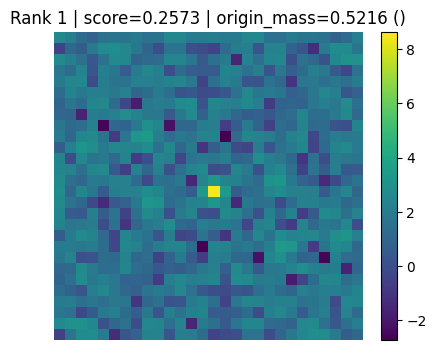


Rank 2
score        : 0.257324
origin_mass  : 0.521625
gamma_star   : 12.320312
s_max_star   : 41015.792685
params       : {'intra_classes': {0}, 'inter_classes': {9}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}


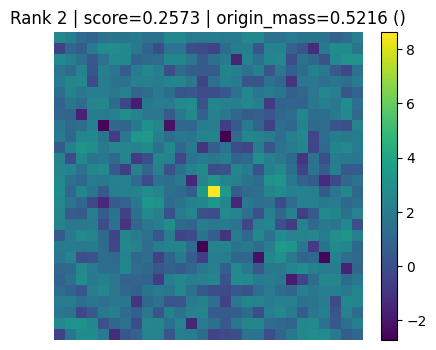


Top 1
score: 0.2573243062393999
params: {'intra_classes': {0}, 'inter_classes': {9}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}
kernel shape: (28, 28)

Top 2
score: 0.2573243062393999
params: {'intra_classes': {0}, 'inter_classes': {9}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}
kernel shape: (28, 28)


In [27]:
search_space = {
    "intra_classes": [{0}],
    "inter_classes": [{9}],
    "time_grid": [[398]],
    "sigma0": [1.0],
    "eps_s": [1e-5],
    "delta_close": [50.0],
    "beta_start": [1e-6],
    "bisection_iters": [10],
}
# search_space = {
#     "intra_classes": [1,7,{1,2,7}],
#     "inter_classes": [{8}, {9}, {8,9,0}],
#     "time_grid": [[200], [300], [398]],
#     "sigma0": [1.0,10.0,100.0],
#     "eps_s": [1e-5],
#     "delta_close": [0.5, 5.0, 50.0],
#     "beta_start": [1e-6],
#     "bisection_iters": [10],
# }

search_out = search_mnist_preconditioner_hyperparams(
    search_space=search_space,
    top_k=15,
    T_steps=400,
    beta_end=0.02,
    solver="SCS",                 
    outer_print_progress=True,
    inner_bisection_logs=False,
    visualize_top_k=True,
    build_dense_M_for_top=True,  # using True builds M
)

output_M = search_out["top_results"]

# print  hyperparameter pairs for selected pairs in output_M
for i, r in enumerate(output_M, start=1):
    print(f"\nTop {i}")
    print("score:", r["score"])
    print("params:", r["params"])
    print("kernel shape:", r["kernel_hw"].shape)   # (28, 28)

In [28]:
# def visualize_preconditioner_effect(
#     mnist_train,
#     M,
#     idx=0,
#     rescale_mode="minmax",   # "minmax" or "clip"
# ):
#     """
#     Visualize the effect of a 784x784 preconditioner M on one MNIST image.

#     Parameters
#     ----------
#     mnist_train : dataset
#         Dataset returned by load_mnist_train().
#     M : np.ndarray or torch.Tensor
#         784 x 784 preconditioner.
#     idx : int
#         Index of image in mnist_train to visualize.
#     rescale_mode : str
#         "clip"   : map transformed image from [-1,1] to [0,1], then clip
#         "minmax" : per-image min/max rescale transformed image to [0,1]

#     Notes
#     -----
#     - The preconditioner is applied to the image in [-1,1].
#     - For visualization, we map back to [0,1].
#     - We also show a difference image (Mx - x), min/max scaled for visibility.
#     """
#     # get one MNIST image in [-1,1]
#     x, y = mnist_train[idx]                 # x has shape [1, 28, 28]
#     x_hw = x[0].numpy().astype(np.float64)  # shape [28, 28]
#     x_vec = vec_img(x_hw)                   # shape [784]

#     # apply preconditioner in [-1,1]
#     if isinstance(M, torch.Tensor):
#         M = M.detach().cpu().numpy()
#     y_vec = M @ x_vec
#     y_hw = unvec_img(y_vec)

#     # original image for display: [-1,1] -> [0,1]
#     x_disp = (x_hw + 1.0) / 2.0
#     x_disp = np.clip(x_disp, 0.0, 1.0)

#     # transformed image for display
#     if rescale_mode == "clip":
#         y_disp = (y_hw + 1.0) / 2.0
#         y_disp = np.clip(y_disp, 0.0, 1.0)
#     elif rescale_mode == "minmax":
#         y_min, y_max = y_hw.min(), y_hw.max()
#         if y_max > y_min:
#             y_disp = (y_hw - y_min) / (y_max - y_min)
#         else:
#             y_disp = np.zeros_like(y_hw)
#     else:
#         raise ValueError("rescale_mode must be 'clip' or 'minmax'")

#     # plot
#     fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))

#     axs[0].imshow(x_disp, cmap="gray")
#     axs[0].set_title(f"Original")
#     axs[0].axis("off")

#     axs[1].imshow(y_disp, cmap="gray")
#     axs[1].set_title(f"Preconditioned\n({rescale_mode})")
#     axs[1].axis("off")

#     plt.tight_layout()
#     plt.show()

#     # print numeric range info too
#     print("Original range in [-1,1] space:")
#     print("Preconditioned range:")
#     print(f"  min = {y_hw.min():.4f}, max = {y_hw.max():.4f}")



# mnist_train = load_mnist_train()
# num_images = np.min([4, len(output_M)])
# for i in range(len(output_M)):
#     M = output_M[i]['M']
#     visualize_preconditioner_effect(mnist_train, M, idx=2, rescale_mode="minmax")



2

In [33]:
print(output_M[0].keys())
# output_M[1]['M']
len(output_M)

# M = torch.rand(784,784, dtype=torch.float32).cpu()
# print(type(M))

# torch.save(M, "M_784.pt")

# print("\nSaved M as M_784.pt")

NameError: name 'output_M' is not defined

In [ ]:
'''
SCS infeasible

'''

In [ ]:
def build_dense_Minv_from_s(s_hw: np.ndarray) -> np.ndarray: 
    assert np.all(s_hw > 0), "Need s[ω] > 0 to build M^{-1}." 
    inv_sqrt_s_hw = 1.0 / np.sqrt(s_hw)
    Minv = np.zeros((D, D), dtype=np.float64) 
    for p in range(D): 
        e = np.zeros((D,), dtype=np.float64) 
        e[p] = 1.0 
        e_hw = unvec_img(e) # apply inverse in Fourier domain 
        E_hat = np.fft.fft2(e_hw, norm="ortho") 
        X_hat = inv_sqrt_s_hw * E_hat 
        x_hw = np.fft.ifft2(X_hat, norm="ortho") 
        x_hw = np.real_if_close(x_hw, tol=1e3) 
        Minv[:, p] = vec_img(np.asarray(x_hw, dtype=np.float64)) 
    return Minv

# -----------------------------
# design
# -----------------------------
def design_mnist_preconditioner(
    intra_classes,
    inter_classes,
    time_grid=None,
    delta_close: float = 0.5,
    sigma0: float = 3.121,
    eps_s: float = 1e-8,
    T_steps: int = 400,
    beta_start: float = 1e-4,
    beta_end: float = 0.02,
    # Means
    placeholder_seed: int = 0,
    max_per_class: int = 5000,
    # Bisection
    gamma_hi_init: float = 1.0,
    gamma_hi_max: float = 200.0,
    bisection_iters: int = 20,
    # CVXPY
    solver: str = "SCS",
    verbose: bool = False,
):
    intra_classes = set(intra_classes)
    inter_classes = set(inter_classes)

    if len(intra_classes & inter_classes) > 0:
        raise ValueError("intra_classes and inter_classes must be disjoint.")

    for c in list(intra_classes | inter_classes):
        if c not in set(range(10)):
            raise ValueError("Classes must be in {0,...,9}.")

    if time_grid is None:
        time_grid = [50, 51, 52]

    g_all = ddpm_g_from_linear_beta_schedule(
        T_steps=T_steps,
        beta_start=beta_start,
        beta_end=beta_end,
    )

    time_grid = [int(t) for t in time_grid if 0 <= int(t) < T_steps]
    if len(time_grid) == 0:
        raise ValueError(
            "time_grid must contain at least one valid index in [0, T_steps-1]."
        )

    g_grid = g_all[time_grid].astype(np.float64)

    mnist_train = load_mnist_train()
    mu_hw = get_class_means(
        mnist_train,
        placeholder_seed=placeholder_seed,
        max_per_class=max_per_class,
    )

    close_pairs = pairs_within(intra_classes)
    far_pairs = pairs_across(intra_classes, inter_classes)

    A_close = abs_dhat_sq_from_means(mu_hw, close_pairs)
    A_far = abs_dhat_sq_from_means(mu_hw, far_pairs)

    problem, s_var, smax_var, gamma_sq_param = build_lp_problem(
        A_close=A_close,
        A_far=A_far,
        g_grid=g_grid,
        delta_close=delta_close,
        sigma0=sigma0,
        eps_s=eps_s,
    )

    gamma_star, s_star, smax_star, hist = bisect_max_gamma(
        problem=problem,
        s_var=s_var,
        smax_var=smax_var,
        gamma_sq_param=gamma_sq_param,
        gamma_hi_init=gamma_hi_init,
        gamma_hi_max=gamma_hi_max,
        bisection_iters=bisection_iters,
        solver=solver,
        verbose_solver=False,  # suppress iteration spam
        print_progress=True,   # one-line per attempt: FEASIBLE/INFEASIBLE + gamma
    )

    s_hw = s_star.reshape(H, W)
    M = build_dense_M_from_s(s_hw)

    return {
        "gamma_star": float(gamma_star),
        "s_star": s_star,
        "s_max_star": float(smax_star),
        "M": M,
        "time_grid": time_grid,
        "g_grid": g_grid,
        "mu_hw": mu_hw,
        "bisect_history": hist,
    }


# -----------------------------
# Example
# -----------------------------
if __name__ == "__main__":
    intra = {8}
    inter = {1}

    out = design_mnist_preconditioner(
        intra_classes=intra,
        inter_classes=inter,
        time_grid=[200],
        delta_close=15.0,
        sigma0=1.0,
        eps_s=1e-4,
        T_steps=400,
        beta_start=1e-5,
        beta_end=0.02,
        placeholder_seed=0,
        bisection_iters=15,
        gamma_hi_init=1.0,
        gamma_hi_max=200.0,
        solver="SCS",
        verbose=True,
    )

    gamma_star = out["gamma_star"]
    s_max_star = out["s_max_star"]
    M = out["M"]

    print("=== Preconditioner design complete ===")
    print(f"gamma_star ≈ {gamma_star:.6f}")
    print(f"s_max_star ≈ {s_max_star:.6f}")
    print(f"M shape: {M.shape}, dtype: {M.dtype}")
    print(f"M Fro norm: {np.linalg.norm(M, ord='fro'):.6f}")

    mnist_train = load_mnist_train()
    x, y = mnist_train[0]  # x: [1, 28, 28]

    x_hw = x[0].numpy().astype(np.float64)
    x_vec = vec_img(x_hw)
    y_vec = M @ x_vec
    y_hw = unvec_img(y_vec)

    print("\n=== Example application to one MNIST image ===")
    print(f"Original label: {int(y)}")
    print(f"x_vec norm: {np.linalg.norm(x_vec):.6f}")
    print(f"y_vec norm: {np.linalg.norm(y_vec):.6f}")
    print(
        f"y_hw stats: min={y_hw.min():.6f}, max={y_hw.max():.6f}, mean={y_hw.mean():.6f}"
    )

    s_hw = out["s_star"].reshape(H, W)
    Minv = build_dense_Minv_from_s(s_hw)
    x_rec = Minv @ y_vec
    rel_err = np.linalg.norm(x_rec - x_vec) / (np.linalg.norm(x_vec) + 1e-12)

    print("\n=== Inversion check (M^{-1} M x) ===")
    print(f"relative reconstruction error: {rel_err:.6e}")

[bracket] gamma=0.0 -> FEASIBLE (status=optimal)
[bracket] gamma=1 -> FEASIBLE (best=1)
[bracket] gamma=2 -> FEASIBLE (best=2)
[bracket] gamma=4 -> FEASIBLE (best=4)
[bracket] gamma=8 -> FEASIBLE (best=8)
[bracket] gamma=16 -> INFEASIBLE (best=8, status=infeasible)
[bisect 00] gamma=12 -> INFEASIBLE (best=8, status=infeasible)
[bisect 01] gamma=10 -> INFEASIBLE (best=8, status=infeasible)
[bisect 02] gamma=9 -> FEASIBLE (best=9)
[bisect 03] gamma=9.5 -> INFEASIBLE (best=9, status=infeasible)


/tmp/ipykernel_405419/633950758.py:45: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver, verbose=verbose_solver)


[bisect 04] gamma=9.25 -> FEASIBLE (best=9.25)
[bisect 05] gamma=9.375 -> FEASIBLE (best=9.375)
[bisect 06] gamma=9.4375 -> FEASIBLE (best=9.4375)
[bisect 07] gamma=9.46875 -> FEASIBLE (best=9.46875)
[bisect 08] gamma=9.48438 -> INFEASIBLE (best=9.46875, status=infeasible)
[bisect 09] gamma=9.47656 -> INFEASIBLE (best=9.46875, status=infeasible)
[bisect 10] gamma=9.47266 -> INFEASIBLE (best=9.46875, status=infeasible)
[bisect 11] gamma=9.4707 -> INFEASIBLE (best=9.46875, status=infeasible)
[bisect 12] gamma=9.46973 -> INFEASIBLE (best=9.46875, status=infeasible)
[bisect 13] gamma=9.46924 -> INFEASIBLE (best=9.46875, status=infeasible)
[bisect 14] gamma=9.46899 -> FEASIBLE (best=9.46899)
=== Preconditioner design complete ===
gamma_star ≈ 9.468994
s_max_star ≈ 58588.535731
M shape: (784, 784), dtype: float64
M Fro norm: 6775.248726

=== Example application to one MNIST image ===
Original label: 5
x_vec norm: 26.788683
y_vec norm: 6484.200323
y_hw stats: min=-242.280795, max=241.820520, 

/tmp/ipykernel_405419/3241162475.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(y_hw, dtype=np.float64)


In [30]:
# ============================================================
# Feasibility check for a given candidate solution
# Drop this immediately after your existing code.
# ============================================================

def _flat_to_hw(idx, W_=W):
    return (int(idx) // W_, int(idx) % W_)


def make_debug_data_from_out(out, intra_classes, inter_classes, delta_close, sigma0, eps_s):
    """
    Convenience wrapper: builds the exact matrices/metadata needed for debugging
    from the output of design_mnist_preconditioner(...).
    """
    intra_classes = set(intra_classes)
    inter_classes = set(inter_classes)

    mu_hw = np.asarray(out["mu_hw"], dtype=np.float64)
    g_grid = np.asarray(out["g_grid"], dtype=np.float64).reshape(-1)
    time_grid = list(out.get("time_grid", range(len(g_grid))))

    close_pairs = pairs_within(intra_classes)
    far_pairs = pairs_across(intra_classes, inter_classes)

    A_close = abs_dhat_sq_from_means(mu_hw, close_pairs)
    A_far = abs_dhat_sq_from_means(mu_hw, far_pairs)

    return {
        "A_close": A_close,
        "A_far": A_far,
        "g_grid": g_grid,
        "time_grid": time_grid,
        "close_pairs": close_pairs,
        "far_pairs": far_pairs,
        "sym_pairs": symmetry_index_pairs(H, W),
        "delta_close": float(delta_close),
        "sigma0": float(sigma0),
        "eps_s": float(eps_s),
    }


def plot_feasibility_diagnostics(report):
    """
    Small, simple diagnostics:
      1) bar chart of worst slack / tolerance margin by block,
      2) sorted box slacks,
      3) heatmaps for close/far blocks when present.
    """
    eq_tol = report["eq_tol"]
    slacks = report["slacks"]

    bar_labels = ["s_max>=0", "s>=eps", "s<=smax", "sym(eq)", "close", "far"]
    bar_values = [
        float(slacks["s_max_nonneg"]),
        float(np.min(slacks["s_lower"])),
        float(np.min(slacks["s_upper"])),
        float(eq_tol - np.max(slacks["sym_abs"])) if slacks["sym_abs"].size > 0 else float(eq_tol),
        float(np.min(slacks["close"])) if slacks["close"].size > 0 else np.nan,
        float(np.min(slacks["far"])) if slacks["far"].size > 0 else np.nan,
    ]

    plt.figure(figsize=(7, 4))
    xs = np.arange(len(bar_labels))
    vals = np.array(bar_values, dtype=np.float64)
    mask = ~np.isnan(vals)
    plt.bar(xs[mask], vals[mask])
    plt.axhline(0.0, linestyle="--")
    plt.xticks(xs, bar_labels, rotation=30, ha="right")
    plt.ylabel("worst slack (or eq_tol - max|eq residual|)")
    plt.title("Worst margin by constraint block")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(np.sort(slacks["s_lower"]), label="s - eps_s")
    plt.plot(np.sort(slacks["s_upper"]), label="s_max - s")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("sorted frequency index")
    plt.ylabel("slack")
    plt.title("Box-constraint slacks")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if slacks["close"].size > 0:
        plt.figure(figsize=(7, 4))
        plt.imshow(slacks["close"], aspect="auto")
        plt.colorbar(label="close slack")
        plt.xlabel("close-pair index")
        plt.ylabel("time-grid index")
        plt.title("Close-constraint slacks")
        plt.tight_layout()
        plt.show()

    if slacks["far"].size > 0:
        plt.figure(figsize=(7, 4))
        plt.imshow(slacks["far"], aspect="auto")
        plt.colorbar(label="far slack")
        plt.xlabel("far-pair index")
        plt.ylabel("time-grid index")
        plt.title("Far-constraint slacks")
        plt.tight_layout()
        plt.show()


def check_candidate_feasibility(
    s,
    s_max,
    gamma,
    dbg,
    eq_tol=1e-7,
    ineq_tol=1e-7,
    verbose=True,
    make_plots=True,
):
    """
    Check whether a candidate (s, s_max) is feasible for the fixed-gamma LP.

    Returns a dictionary containing:
      - per-block pass/fail flags,
      - worst violation by block,
      - the full slack arrays,
      - the tightest/most active constraints.
    """
    s = np.asarray(s, dtype=np.float64).reshape(-1)
    if s.shape != (D,):
        raise ValueError(f"s must have shape ({D},), got {s.shape}")
    s_max = float(s_max)
    gamma = float(gamma)

    A_close = dbg["A_close"]
    A_far = dbg["A_far"]
    g_grid = np.asarray(dbg["g_grid"], dtype=np.float64).reshape(-1)
    time_grid = list(dbg["time_grid"])
    close_pairs = list(dbg["close_pairs"])
    far_pairs = list(dbg["far_pairs"])
    sym_pairs = list(dbg["sym_pairs"])
    delta_close = float(dbg["delta_close"])
    sigma0 = float(dbg["sigma0"])
    eps_s = float(dbg["eps_s"])

    # ----- basic slacks -----
    slack_smax_nonneg = float(s_max)
    slack_s_lower = s - eps_s
    slack_s_upper = s_max - s

    # ----- symmetry residuals -----
    if len(sym_pairs) > 0:
        sym_diff = np.array([s[i] - s[j] for (i, j) in sym_pairs], dtype=np.float64)
        sym_abs = np.abs(sym_diff)
    else:
        sym_diff = np.zeros((0,), dtype=np.float64)
        sym_abs = np.zeros((0,), dtype=np.float64)

    # ----- close slacks: delta_close^2 - g * (A_close @ s) -----
    if A_close.shape[0] > 0:
        close_base = A_close @ s
        close_lhs = g_grid[:, None] * close_base[None, :]
        close_slack = (delta_close ** 2) - close_lhs
    else:
        close_lhs = np.zeros((len(g_grid), 0), dtype=np.float64)
        close_slack = np.zeros((len(g_grid), 0), dtype=np.float64)

    # ----- far slacks: g*(A_far @ s) - gamma^2*(1 + sigma0^2 * g * s_max) -----
    if A_far.shape[0] > 0:
        far_base = A_far @ s
        far_lhs = g_grid[:, None] * far_base[None, :]
        far_rhs = (gamma ** 2) * (1.0 + (sigma0 ** 2) * g_grid * s_max)[:, None]
        far_slack = far_lhs - far_rhs
    else:
        far_lhs = np.zeros((len(g_grid), 0), dtype=np.float64)
        far_rhs = np.zeros((len(g_grid), 0), dtype=np.float64)
        far_slack = np.zeros((len(g_grid), 0), dtype=np.float64)

    # ----- per-block summaries -----
    min_s_lower = float(np.min(slack_s_lower))
    min_s_upper = float(np.min(slack_s_upper))
    max_sym_abs = float(np.max(sym_abs)) if sym_abs.size > 0 else 0.0
    min_close = float(np.min(close_slack)) if close_slack.size > 0 else np.inf
    min_far = float(np.min(far_slack)) if far_slack.size > 0 else np.inf

    block_ok = {
        "s_max_nonneg": slack_smax_nonneg >= -ineq_tol,
        "s_lower_bound": min_s_lower >= -ineq_tol,
        "s_upper_bound": min_s_upper >= -ineq_tol,
        "symmetry": max_sym_abs <= eq_tol,
        "close": (min_close >= -ineq_tol) if close_slack.size > 0 else True,
        "far": (min_far >= -ineq_tol) if far_slack.size > 0 else True,
    }

    max_violation = {
        "s_max_nonneg": max(-slack_smax_nonneg, 0.0),
        "s_lower_bound": max(-min_s_lower, 0.0),
        "s_upper_bound": max(-min_s_upper, 0.0),
        "symmetry": max(max_sym_abs - eq_tol, 0.0),
        "close": max(-min_close, 0.0) if close_slack.size > 0 else 0.0,
        "far": max(-min_far, 0.0) if far_slack.size > 0 else 0.0,
    }

    is_feasible = all(block_ok.values())

    # ----- tightest constraints -----
    i_lower = int(np.argmin(slack_s_lower))
    i_upper = int(np.argmin(slack_s_upper))

    if sym_abs.size > 0:
        i_sym = int(np.argmax(sym_abs))
        sym_pair = sym_pairs[i_sym]
        sym_info = {
            "max_abs_diff": max_sym_abs,
            "pair_flat": sym_pair,
            "pair_hw": (_flat_to_hw(sym_pair[0]), _flat_to_hw(sym_pair[1])),
        }
    else:
        sym_info = None

    close_info = None
    if close_slack.size > 0:
        flat = int(np.argmin(close_slack))
        t_idx, p_idx = np.unravel_index(flat, close_slack.shape)
        close_info = {
            "min_slack": float(close_slack[t_idx, p_idx]),
            "time_index": int(time_grid[t_idx]),
            "g": float(g_grid[t_idx]),
            "pair_index": int(p_idx),
            "pair": close_pairs[p_idx],
            "lhs": float(close_lhs[t_idx, p_idx]),
            "rhs": float(delta_close ** 2),
        }

    far_info = None
    if far_slack.size > 0:
        flat = int(np.argmin(far_slack))
        t_idx, p_idx = np.unravel_index(flat, far_slack.shape)
        far_info = {
            "min_slack": float(far_slack[t_idx, p_idx]),
            "time_index": int(time_grid[t_idx]),
            "g": float(g_grid[t_idx]),
            "pair_index": int(p_idx),
            "pair": far_pairs[p_idx],
            "lhs": float(far_lhs[t_idx, p_idx]),
            "rhs": float(far_rhs[t_idx, p_idx]),
        }

    report = {
        "gamma": gamma,
        "s": s,
        "s_max": s_max,
        "eq_tol": float(eq_tol),
        "ineq_tol": float(ineq_tol),
        "is_feasible": bool(is_feasible),
        "block_ok": block_ok,
        "max_violation": max_violation,
        "tightest": {
            "s_lower": {
                "min_slack": min_s_lower,
                "flat_index": i_lower,
                "hw_index": _flat_to_hw(i_lower),
            },
            "s_upper": {
                "min_slack": min_s_upper,
                "flat_index": i_upper,
                "hw_index": _flat_to_hw(i_upper),
            },
            "s_max_nonneg": {
                "slack": slack_smax_nonneg,
            },
            "symmetry": sym_info,
            "close": close_info,
            "far": far_info,
        },
        "slacks": {
            "s_max_nonneg": slack_smax_nonneg,
            "s_lower": slack_s_lower,
            "s_upper": slack_s_upper,
            "sym_abs": sym_abs,
            "close": close_slack,
            "far": far_slack,
        },
    }

    if verbose:
        print("=== Feasibility check ===")
        print(f"gamma checked: {gamma:.12g}")
        print(
            f"status: {'FEASIBLE' if is_feasible else 'INFEASIBLE'} "
            f"(ineq_tol={ineq_tol:.1e}, eq_tol={eq_tol:.1e})"
        )
        print("max violation by block:")
        for k in ["s_max_nonneg", "s_lower_bound", "s_upper_bound", "symmetry", "close", "far"]:
            print(f"{k:>16s}: {max_violation[k]:.3e}")

        print("tightest slacks:")
        print(
            f"  s >= eps_s     : {report['tightest']['s_lower']['min_slack']:.3e} "
            f"at ω={report['tightest']['s_lower']['hw_index']}"
        )
        print(
            f"  s <= s_max     : {report['tightest']['s_upper']['min_slack']:.3e} "
            f"at ω={report['tightest']['s_upper']['hw_index']}"
        )
        print(f"  s_max >= 0     : {slack_smax_nonneg:.3e}")
        if sym_info is not None:
            print(
                f"  symmetry       : abs diff {sym_info['max_abs_diff']:.3e} "
                f"at ω-pair={sym_info['pair_hw']}"
            )
        if close_info is not None:
            print(
                f"  close block    : slack {close_info['min_slack']:.3e} "
                f"at t={close_info['time_index']}, pair={close_info['pair']}"
            )
        if far_info is not None:
            print(
                f"  far block      : slack {far_info['min_slack']:.3e} "
                f"at t={far_info['time_index']}, pair={far_info['pair']}"
            )

    if make_plots:
        plot_feasibility_diagnostics(report)

    return report

=== Feasibility check ===
gamma checked: 9.46899414062
status: INFEASIBLE (ineq_tol=1.0e-07, eq_tol=1.0e-07)
max violation by block:
    s_max_nonneg: 0.000e+00
   s_lower_bound: 0.000e+00
   s_upper_bound: 4.130e-03
        symmetry: 0.000e+00
           close: 0.000e+00
             far: 4.371e-01
tightest slacks:
  s >= eps_s     : 2.919e+04 at ω=(14, 14)
  s <= s_max     : -4.130e-03 at ω=(0, 0)
  s_max >= 0     : 5.859e+04
  symmetry       : abs diff 9.423e-08 at ω-pair=((1, 3), (27, 25))
  far block      : slack -4.371e-01 at t=200, pair=(8, 1)


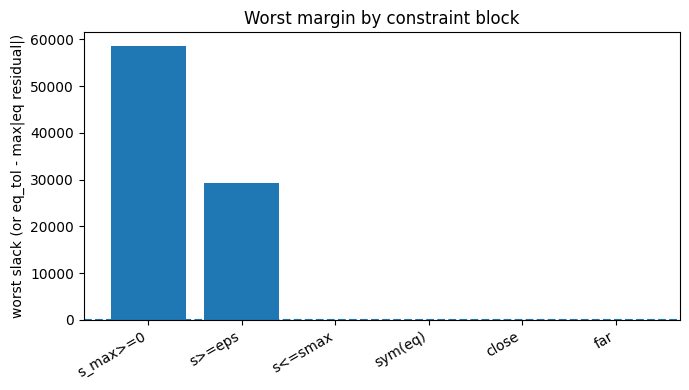

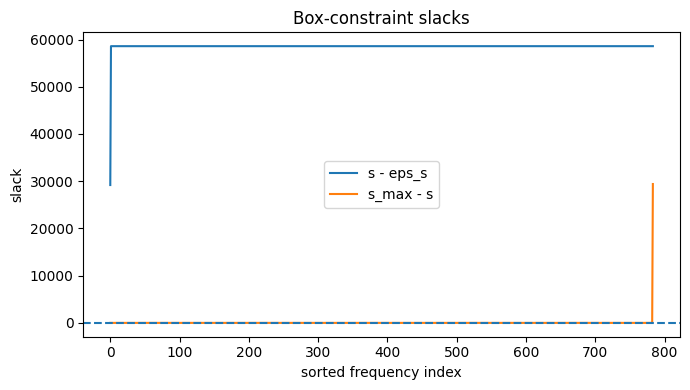

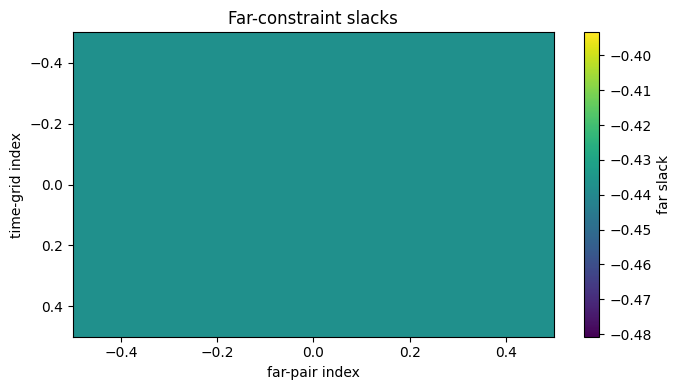

In [35]:
# -----------------------------
# Example usage
# -----------------------------
dbg = make_debug_data_from_out(
    out=out,
    intra_classes=intra,
    inter_classes=inter,
    delta_close=15.0,
    sigma0=1.0,
    eps_s=1e-4,
)

# 1) Check the actual returned solution
feas = check_candidate_feasibility(
    s=out["s_star"],
    s_max=out["s_max_star"],
    gamma=out["gamma_star"],
    dbg=dbg,
    eq_tol=1e-7,
    ineq_tol=1e-7,
    verbose=True,
    make_plots=True,
)

# # 2) Check strict feasibility at that same gamma
# strict = check_problem_strict_feasibility(
#     gamma=out["gamma_star"],
#     dbg=dbg,
#     solver="SCS",  
#     margin_tol=1e-8,
#     verbose=True,
#     make_plots=True,
# )

# # 3) Very useful sanity check:
# #    gamma_star is often on the boundary, so also test a slightly smaller gamma.
# strict_looser = check_problem_strict_feasibility(
#     gamma=0.99 * out["gamma_star"],
#     dbg=dbg,
#     solver="SCS",
#     margin_tol=1e-8,
#     verbose=True,
#     make_plots=False,
# )